# Wprowadzenie do listy

Użyjemy `make_classification` z biblioteki scikit-learn, aby stworzyć wysoce niezbalansowany zbiór (ok. 15% klasy pozytywnej). Dodatkowo, zgrupujemy dane przypisując każdemu użytkownikowi dokładnie 7 interakcji.


In [ ]:
# !pip install imbalanced-learn

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Generowanie danych: 700 interakcji, 15% klasy 1 (Match), 85% klasy 0 (Brak dopasowania)
X, y = make_classification(n_samples=700, n_features=10, n_informative=5,
                           n_redundant=2, n_classes=2, weights=[0.85, 0.15],
                           random_state=42)

# Grupowanie po użytkownikach (100 użytkowników po 7 interakcji)
user_ids = np.repeat(np.arange(100), 7)
df = pd.DataFrame(X, columns=[f'cecha_{i}' for i in range(10)])
df['user_id'] = user_ids
df['target'] = y

# Podział na zbiór treningowy i testowy w oparciu o użytkowników
# Użytkownicy 0-74: Trening, Użytkownicy 75-99: Test
train_df = df[df['user_id'] < 75].copy()
test_df = df[df['user_id'] >= 75].copy()

X_train = train_df.drop(columns=['user_id', 'target'])
y_train = train_df['target']
X_test = test_df.drop(columns=['user_id', 'target'])
y_test = test_df['target']

print(f"Dane treningowe: {X_train.shape}, Klasy: {np.bincount(y_train)}")
print(f"Dane testowe: {X_test.shape}, Klasy: {np.bincount(y_test)}")


Dane treningowe: (525, 10), Klasy: [448  77]
Dane testowe: (175, 10), Klasy: [146  29]


Uczymy klasyczną regresję logistyczną i sprawdzamy wyniki.

In [2]:
from sklearn.linear_model import LogisticRegression
from imblearn.metrics import classification_report_imbalanced

baseline_model = LogisticRegression(random_state=42)
baseline_model.fit(X_train, y_train)
y_pred = baseline_model.predict(X_test)
y_probs = baseline_model.predict_proba(X_test)[:, 1]

print("Raport z Klasyfikacji (Model Bazowy)")
print(classification_report_imbalanced(y_test, y_pred))


Raport z Klasyfikacji (Model Bazowy)
                   pre       rec       spe        f1       geo       iba       sup

          0       0.88      0.99      0.34      0.93      0.58      0.36       146
          1       0.83      0.34      0.99      0.49      0.58      0.32        29

avg / total       0.88      0.88      0.45      0.86      0.58      0.35       175



Algorytm t-SNE pozwala na redukcję wymiarów do 2D w celu wizualizacji. Zobaczymy przestrzeń oryginalną oraz to, co dzieje się po nałożeniu syntetycznych próbek przez SMOTE z biblioteki `imbalanced-learn`.

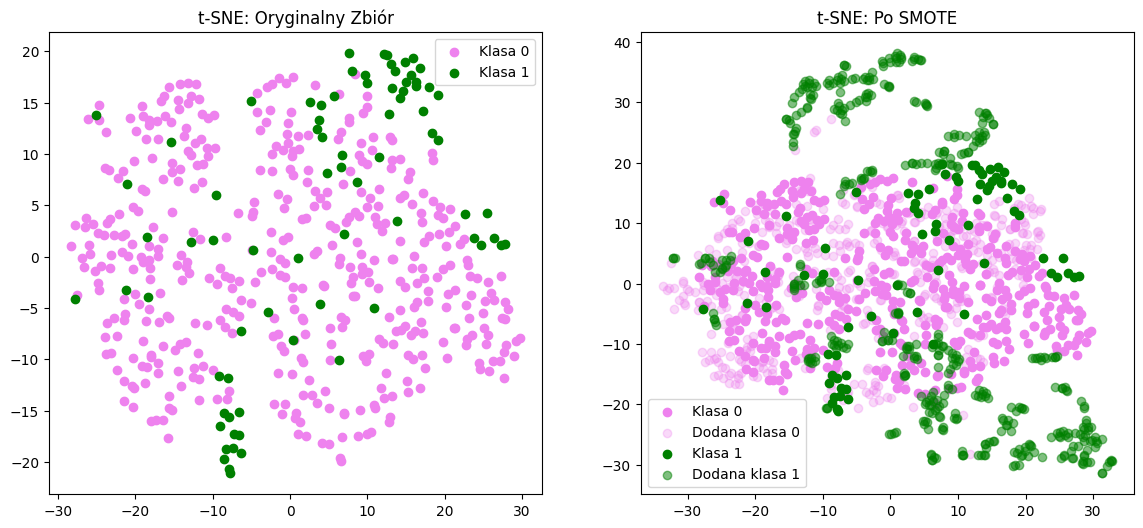

In [3]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# 1. t-SNE na oryginalnych danych treningowych
tsne = TSNE(n_components=2, random_state=42)
X_tsne_raw = tsne.fit_transform(X_train)

# 2. Oversampling przy użyciu SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 3. t-SNE na powiększonym zbiorze ze SMOTE
X_tsne_smote = tsne.fit_transform(X_train_smote)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(X_tsne_raw[y_train==0, 0], X_tsne_raw[y_train==0, 1], label='Klasa 0', alpha=1, c='violet')
axes[0].scatter(X_tsne_raw[y_train==1, 0], X_tsne_raw[y_train==1, 1], label='Klasa 1', alpha=1, c='green')
axes[0].set_title("t-SNE: Oryginalny Zbiór")
axes[0].legend()

axes[1].scatter(X_tsne_raw[y_train==0, 0], X_tsne_raw[y_train==0, 1], label='Klasa 0', alpha=1, c='violet')
axes[1].scatter(X_tsne_smote[y_train_smote==0, 0], X_tsne_smote[y_train_smote==0, 1], label='Dodana klasa 0',  alpha=0.3, c='violet')
axes[1].scatter(X_tsne_raw[y_train==1, 0], X_tsne_raw[y_train==1, 1], label='Klasa 1', alpha=1, c='green')
axes[1].scatter(X_tsne_smote[y_train_smote==1, 0], X_tsne_smote[y_train_smote==1, 1], label='Dodana klasa 1', alpha=0.5, c='green')
axes[1].set_title("t-SNE: Po SMOTE")
axes[1].legend()

plt.show()


## Precision@K i MRR
W modelach biznesowych często ważna jest kolejność wyświetlanych rekomendacji (pomyśl np. o google albo allegro). Dlatego dzielimy wyniki per-użytkownik i sortujemy malejąco po przewidywanym prawdopodobieństwie bycia w klasie 1 (Match).

In [4]:
import random


def bogosort(arr):
    """Sortowanie w porządku malejącym."""
    def _is_sorted_desc(arr):
        for i in range(len(arr) - 1):
            if arr[i]['prob'] < arr[i+1]['prob']:
                return False
        return True
    while not _is_sorted_desc(arr):
        random.shuffle(arr)
    return arr

# Przygotowanie ramki z predykcjami
test_df['prob'] = y_probs

user_precisions = []
user_reciprocal_ranks = []
k_value = 3


for user_id, group in test_df.groupby('user_id'):
    # Zbieramy dane do posortowania
    items = group[['target', 'prob']].to_dict(orient='records')

    # Sortujemy
    sorted_items = bogosort(items)

    # Wyciągamy rzeczywiste etykiety po posortowaniu malejąco względem prawdopodobieństwa
    sorted_targets = [item['target'] for item in sorted_items]

    # Jeśli użytkownik w ogóle nie miał żadnego prawdziwego "Matcha", pomijamy go w statystykach
    if sum(sorted_targets) == 0:
        continue

    # 1. Precision@K
    top_k_targets = sorted_targets[:k_value]
    precision_user = sum(top_k_targets) / k_value
    user_precisions.append(precision_user)

    # 2. Reciprocal Rank (RR)
    # Szukamy pierwszej jedynki (indeksujemy od 1)
    true_positions = [idx for idx, val in enumerate(sorted_targets, 1) if val == 1]
    if len(true_positions) > 0:
        first_match_position = true_positions[0]
        user_reciprocal_ranks.append(1.0 / first_match_position)
    else:
        user_reciprocal_ranks.append(0.0)

mean_precision_at_k = np.mean(user_precisions)
mean_reciprocal_rank = np.mean(user_reciprocal_ranks)

print(f"--- WYNIKI REKOMENDACYJNE dla K={k_value} ---")
print(f"Mean Precision@{k_value}: {mean_precision_at_k * 100:.2f}%")
print(f"Mean Reciprocal Rank (MRR): {mean_reciprocal_rank:.3f}")



--- WYNIKI REKOMENDACYJNE dla K=3 ---
Mean Precision@3: 46.67%
Mean Reciprocal Rank (MRR): 0.967
